In [1]:
!git clone https://github.com/sharul-ayub/malaysia-bank-employee-sentiment-analysis.git
%cd malaysia-bank-employee-sentiment-analysis

Cloning into 'malaysia-bank-employee-sentiment-analysis'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 95 (delta 44), reused 27 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 468.97 KiB | 6.01 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/malaysia-bank-employee-sentiment-analysis


# 04 — Tokenization, Stopword Removal and Lemmatization

This notebook:

1. Loads the cleaned sentence dataset.
2. Tokenizes text with spaCy.
3. Removes stopwords while retaining sentiment-sensitive words.
4. Lemmatizes the remaining tokens.
5. Rejoins the tokens into `processed_text`.
6. Produces optional word clouds.
7. Saves a model-ready dataset.

> The pasted source code applied the spaCy preprocessing function to a Python list. Here it is applied correctly by joining the tokens before lemmatization.

In [2]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(".")
INPUT_PATH = PROJECT_ROOT / "data" / "processed" / "02_sentences_labeled_processed.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_text_labelled = pd.read_csv(INPUT_PATH)

print("Loaded:", INPUT_PATH)
print("Rows:", len(df_text_labelled))
display(df_text_labelled.head())

Loaded: data/processed/02_sentences_labeled_processed.csv
Rows: 1273


,sentiment,review_text,review_text_original,review_text_encoding_fixed,review_text_cleaned,encoding_changed,contraction_changed,non_english_words
0,Negative,the environment is good but the basic is too low,the environment is good but the basic is too low.,the environment is good but the basic is too low.,the environment is good but the basic is too low.,False,False,[]
1,Negative,still a lot of manual work and very volume bas...,still a lot of manual work and very volume bas...,still a lot of manual work and very volume bas...,still a lot of manual work and very volume bas...,False,False,[]
2,Negative,only give short break,only give short break,only give short break,only give short break,False,False,[]
3,Negative,but depends on your tolerance with the culture,but depends on your tolerance with the culture,but depends on your tolerance with the culture,but depends on your tolerance with the culture,False,False,[]
4,Negative,everything is manual and use a lot of paper,everything is manual and use a lot of paper.,everything is manual and use a lot of paper.,everything is manual and use a lot of paper.,False,False,[]


## Install and load spaCy

In [3]:
%pip install -q spacy

In [ ]:
# Run once in a new environment if the model is not installed:
# !python -m spacy download en_core_web_sm

In [4]:
import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    raise OSError(
        "spaCy model 'en_core_web_sm' is not installed. "
        "Run: !python -m spacy download en_core_web_sm"
    )

## Tokenization

In [5]:
def tokenize_text(text):
    doc = nlp(str(text))
    return [token.text for token in doc]

df_text_labelled["tokens"] = (
    df_text_labelled["review_text"]
    .apply(tokenize_text)
)

display(
    df_text_labelled[
        ["review_text", "tokens"]
    ].head()
)

,review_text,tokens
0,the environment is good but the basic is too low,"[the, environment, is, good, but, the, basic, ..."
1,still a lot of manual work and very volume bas...,"[still, a, lot, of, manual, work, and, very, v..."
2,only give short break,"[only, give, short, break]"
3,but depends on your tolerance with the culture,"[but, depends, on, your, tolerance, with, the,..."
4,everything is manual and use a lot of paper,"[everything, is, manual, and, use, a, lot, of,..."


## Stopword removal

`not`, `no`, `never`, and `but` are retained because they can materially change sentiment interpretation.

In [6]:
negation_words = {
    "no",
    "not",
    "never",
    "but"
}

def remove_stopwords_keep_negation(text):
    doc = nlp(str(text))

    return [
        token.text
        for token in doc
        if (
            not token.is_space
            and not token.is_punct
            and (
                not token.is_stop
                or token.text.lower() in negation_words
            )
        )
    ]

df_text_labelled["tokens_no_stopwords"] = (
    df_text_labelled["review_text"]
    .apply(remove_stopwords_keep_negation)
)

display(
    df_text_labelled[
        ["review_text", "tokens_no_stopwords"]
    ].head()
)

,review_text,tokens_no_stopwords
0,the environment is good but the basic is too low,"[environment, good, but, basic, low]"
1,still a lot of manual work and very volume bas...,"[lot, manual, work, volume, based, key, perfor..."
2,only give short break,"[short, break]"
3,but depends on your tolerance with the culture,"[but, depends, tolerance, culture]"
4,everything is manual and use a lot of paper,"[manual, use, lot, paper]"


## Lemmatization

In [7]:
def lemmatize_tokens(tokens):
    doc = nlp(" ".join(map(str, tokens)))

    return [
        token.lemma_.lower()
        for token in doc
        if (
            not token.is_space
            and not token.is_punct
        )
    ]

df_text_labelled["lemmas"] = (
    df_text_labelled["tokens_no_stopwords"]
    .apply(lemmatize_tokens)
)

display(
    df_text_labelled[
        ["review_text", "tokens_no_stopwords", "lemmas"]
    ].head()
)

,review_text,tokens_no_stopwords,lemmas
0,the environment is good but the basic is too low,"[environment, good, but, basic, low]","[environment, good, but, basic, low]"
1,still a lot of manual work and very volume bas...,"[lot, manual, work, volume, based, key, perfor...","[lot, manual, work, volume, base, key, perform..."
2,only give short break,"[short, break]","[short, break]"
3,but depends on your tolerance with the culture,"[but, depends, tolerance, culture]","[but, depend, tolerance, culture]"
4,everything is manual and use a lot of paper,"[manual, use, lot, paper]","[manual, use, lot, paper]"


## Convert tokens back to text

In [8]:
df_text_labelled["processed_text"] = (
    df_text_labelled["lemmas"]
    .apply(lambda tokens: " ".join(tokens))
)

display(
    df_text_labelled[
        ["review_text", "lemmas", "processed_text"]
    ].head(10)
)

,review_text,lemmas,processed_text
0,the environment is good but the basic is too low,"[environment, good, but, basic, low]",environment good but basic low
1,still a lot of manual work and very volume bas...,"[lot, manual, work, volume, base, key, perform...",lot manual work volume base key performance in...
2,only give short break,"[short, break]",short break
3,but depends on your tolerance with the culture,"[but, depend, tolerance, culture]",but depend tolerance culture
4,everything is manual and use a lot of paper,"[manual, use, lot, paper]",manual use lot paper
5,the company only side customer,"[company, customer]",company customer
6,but usually management would keep,"[but, usually, management]",but usually management
7,overall in placename if working in banking can...,"[overall, placename, working, banking, live, g...",overall placename working banking live good li...
8,however the role requires a significant amount...,"[role, require, significant, self, direct, lea...",role require significant self direct learning
9,stay back almost everyday,"[stay, everyday]",stay everyday


## Word clouds

In [9]:
%pip install -q wordcloud matplotlib

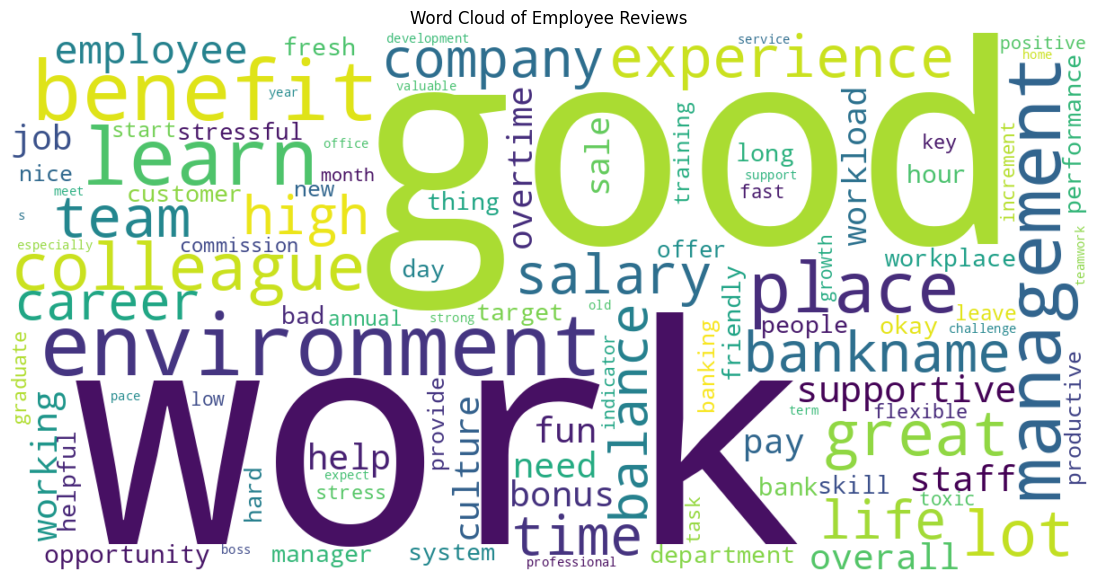

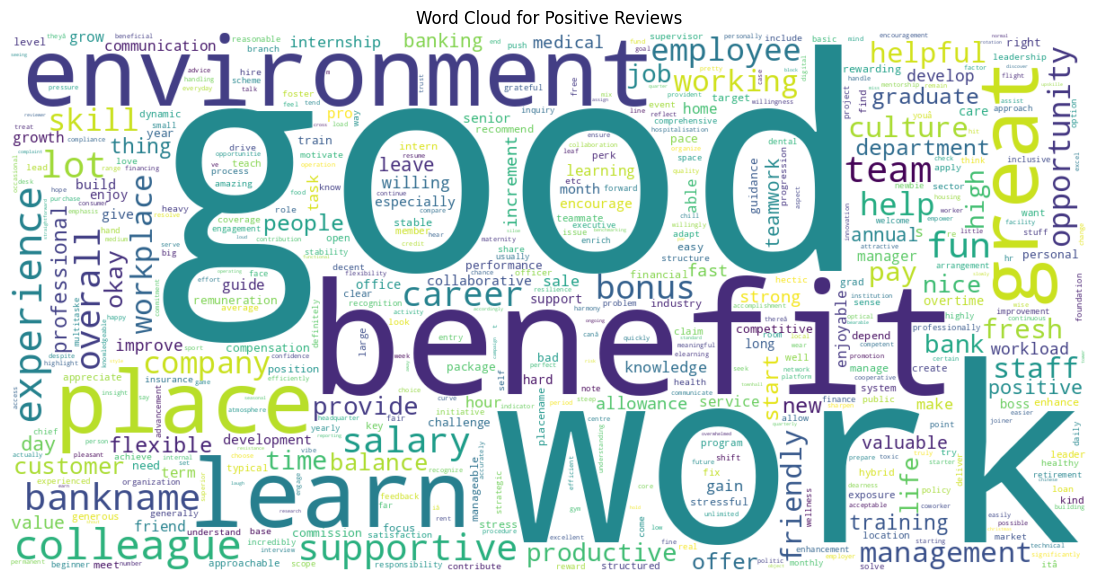

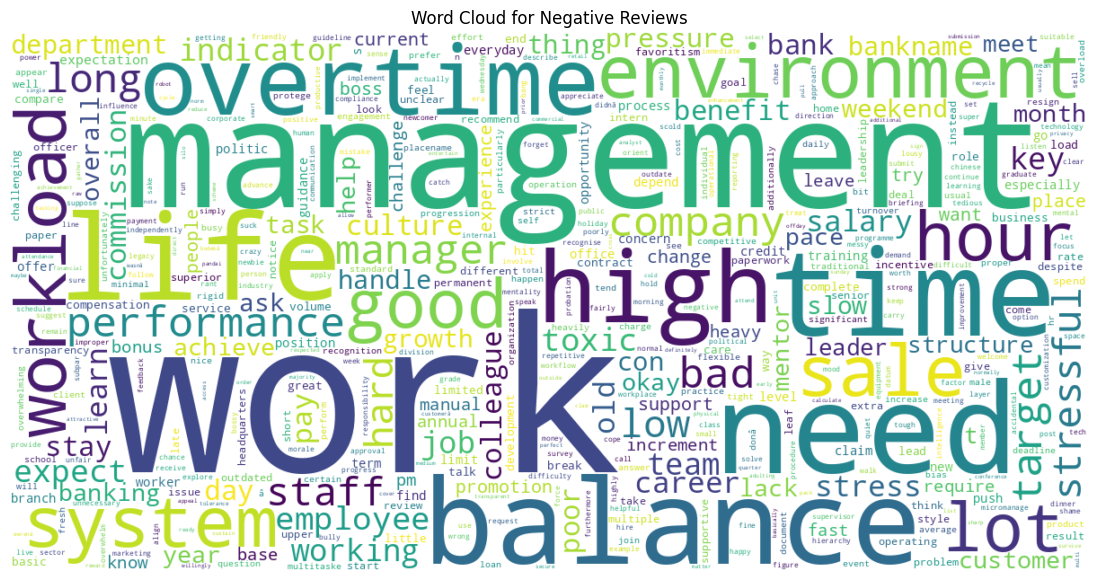

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(
    df_text_labelled["processed_text"]
    .dropna()
    .astype(str)
)

if all_text.strip():
    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=100,
        collocations=False
    ).generate(all_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Employee Reviews")
    plt.show()

for sentiment_label in ["Positive", "Negative"]:
    sentiment_text = " ".join(
        df_text_labelled.loc[
            df_text_labelled["sentiment"] == sentiment_label,
            "processed_text"
        ]
        .dropna()
        .astype(str)
    )

    if sentiment_text.strip():
        wc = WordCloud(
            width=1200,
            height=600,
            background_color="white",
            max_words=500,
            collocations=False
        ).generate(sentiment_text)

        plt.figure(figsize=(14, 7))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Word Cloud for {sentiment_label} Reviews")
        plt.show()

## Save model-ready dataset

In [11]:
output_path = PROCESSED_DIR / "03_model_ready.csv"

df_text_labelled.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", output_path)

Saved: data/processed/03_model_ready.csv
